In [44]:
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display
import threading
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import numpy as np
from scipy.optimize import minimize
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy import stats
import random
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
random.seed(42)

In [45]:

df=pd.read_csv('/content/D1_UK_Beans_Brand_PPG.csv')
df.fillna(0,inplace=True)
unique_ppg=df.PPG.unique()
unique_ppg

array(['Others', 'Standard Multi', 'Standard Single', 'Small Single',
       'Small Multi', 'Small SNAP POTS'], dtype=object)

In [46]:
df.columns

Index(['Market', 'Channel', 'Region', 'Category', 'SubCategory', 'Brand',
       'Variant', 'PackType', 'PPG', 'PackSize', 'L1_Brand', 'L2_PPG', 'Year',
       'Month', 'Week', 'Date', 'SalesValue', 'Volume', 'VolumeUnits', 'D1',
       'PPU', 'PPL', 'Cat_Vol_all_Chn', 'Cat_Vol_in_Chn', 'Seasonality',
       'Trend', 'Cat_Sales_in_Chn', 'Volume_sum_cann', 'D1_cann',
       'D1_Comp@Direct', 'D1_Comp@Indirect', 'PPU_cann', 'PPU_Comp@Direct',
       'PPU_Comp@Indirect', 'PPL_cann', 'PPL_Comp@Direct', 'PPL_Comp@Indirect',
       'Up_Down_Index', 'Cat_Pr_Index'],
      dtype='object')

In [47]:
df['Revenue']=df['Volume']*df['PPL']
market_share = df.groupby(['Channel', 'PPG', 'Brand'])['Revenue'].sum().reset_index()
market_share

,Channel,PPG,Brand,Revenue
0,Convenience,Others,BRANSTON,8.800700e+03
1,Convenience,Others,HEINZ Standard,1.026854e+05
2,Convenience,Others,Restofcategory,3.702560e+03
3,Convenience,Small Multi,HEINZ Standard,1.706432e+06
4,Convenience,Small SNAP POTS,HEINZ Standard,2.271407e+06
...,...,...,...,...
67,Tesco,Standard Single,HEINZ Flavoured,5.151132e+06
68,Tesco,Standard Single,HEINZ Standard,6.304159e+07
69,Tesco,Standard Single,Private Label Std,5.009961e+07
70,Tesco,Standard Single,Private Label Value,9.514815e+06


In [48]:
sum_market_share=market_share.groupby(['Channel'])['Revenue'].sum().reset_index()
sum_market_share

,Channel,Revenue
0,Convenience,5.205724e+07
1,Iceland,4.656602e+07
2,Supermarkets,8.134279e+08
3,Tesco,3.009451e+08


In [49]:
# Ensure 'final_market_share' is initialized
market_share['final_market_share'] = 0  # Initialize with zeros or NaN

# Loop through each unique channel and calculate final market share
unique_channels = df['Channel'].unique()
for ch in unique_channels:
    # Calculate and assign final market share for the current channel
    total_market_share = sum_market_share[sum_market_share['Channel'] == ch]['Revenue'].values[0]
    market_share.loc[market_share['Channel'] == ch, 'final_market_share'] = (
        market_share.loc[market_share['Channel'] == ch, 'Revenue'] / total_market_share
    )
market_share['final_market_share']=market_share['final_market_share']*100
market_share = market_share.round(2)

In [50]:
market_share

,Channel,PPG,Brand,Revenue,final_market_share
0,Convenience,Others,BRANSTON,8800.70,0.02
1,Convenience,Others,HEINZ Standard,102685.44,0.20
2,Convenience,Others,Restofcategory,3702.56,0.01
3,Convenience,Small Multi,HEINZ Standard,1706432.24,3.28
4,Convenience,Small SNAP POTS,HEINZ Standard,2271407.02,4.36
...,...,...,...,...,...
67,Tesco,Standard Single,HEINZ Flavoured,5151132.44,1.71
68,Tesco,Standard Single,HEINZ Standard,63041587.51,20.95
69,Tesco,Standard Single,Private Label Std,50099608.43,16.65
70,Tesco,Standard Single,Private Label Value,9514814.85,3.16


In [51]:
right_combination=market_share[market_share['final_market_share']>=1].reset_index()

In [52]:
right_combination

,index,Channel,PPG,Brand,Revenue,final_market_share
0,3,Convenience,Small Multi,HEINZ Standard,1.706432e+06,3.28
1,4,Convenience,Small SNAP POTS,HEINZ Standard,2.271407e+06,4.36
2,6,Convenience,Small Single,HEINZ Standard,7.694068e+06,14.78
3,7,Convenience,Small Single,Private Label Std,6.763344e+05,1.30
4,9,Convenience,Standard Multi,BRANSTON,4.029657e+06,7.74
5,10,Convenience,Standard Multi,HEINZ Standard,1.158305e+07,22.25
6,11,Convenience,Standard Multi,Private Label Std,6.154817e+05,1.18
7,12,Convenience,Standard Single,BRANSTON,2.132243e+06,4.10
8,14,Convenience,Standard Single,HEINZ Standard,1.556187e+07,29.89
9,15,Convenience,Standard Single,Private Label Std,5.011171e+06,9.63


In [53]:
sum_market_share=market_share.groupby(['Channel'])['final_market_share'].sum().reset_index()
sum_market_share

,Channel,final_market_share
0,Convenience,100.01
1,Iceland,100.01
2,Supermarkets,100.00
3,Tesco,100.01


In [54]:
def remove_outliers_iqr(df):

    numeric_cols = df.select_dtypes(include='number').columns
    # numeric_cols=['SalesValue']
    for col in numeric_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter out outliers for the current column
        df = df[~((df[col] < lower_bound) | (df[col] > upper_bound))]

    return df

In [55]:
list_df=[]
unique_channel=df.Channel.unique()
for ch in unique_channel:
  df_ch=df[df['Channel']==ch]

  unique_ppg=df_ch.PPG.unique()
  # unique_ppg=['Standard Multi']
  for ppg in unique_ppg:
    df_ch_ppg=df_ch[df_ch['PPG']==ppg]
    unique_brand=df_ch_ppg.Brand.unique()


    df_ch_ppg=df_ch_ppg[['Market', 'Channel', 'Region', 'Category', 'SubCategory', 'Brand',
          'Variant', 'PackType', 'PPG', 'PackSize', 'Year',
          'Month', 'Week', 'Date', 'SalesValue', 'Volume', 'VolumeUnits', 'D1',
          'PPU', 'PPL', 'Cat_Vol_all_Chn', 'Cat_Vol_in_Chn', 'Seasonality',
          'Trend', 'Cat_Sales_in_Chn', 'Volume_sum_cann', 'D1_cann',
          'D1_Comp@Direct', 'D1_Comp@Indirect', 'PPU_cann', 'PPU_Comp@Direct',
          'PPU_Comp@Indirect', 'PPL_cann', 'PPL_Comp@Direct', 'PPL_Comp@Indirect',
          'Up_Down_Index', 'Cat_Pr_Index']]
    df_ch_ppg.dropna(inplace=True)
    df_ch_ppg.reset_index(drop=True,inplace=True)
    # df_ch_ppg=remove_outliers_iqr(df_ch_ppg)
    if len(df_ch_ppg)>30:


      print(f'enough data points( {len(df_ch_ppg)}   ) for combination of Channel>>> {ch} and PPG >>> {ppg} and available brands are {unique_brand} ')
      list_df.append(df_ch_ppg)

enough data points( 255   ) for combination of Channel>>> Convenience and PPG >>> Others and available brands are ['BRANSTON' 'HEINZ Standard' 'Restofcategory'] 
enough data points( 492   ) for combination of Channel>>> Convenience and PPG >>> Standard Multi and available brands are ['BRANSTON' 'HEINZ Standard' 'Private Label Std'] 
enough data points( 817   ) for combination of Channel>>> Convenience and PPG >>> Standard Single and available brands are ['BRANSTON' 'HEINZ Flavoured' 'HEINZ Standard' 'Private Label Std'
 'Restofcategory'] 
enough data points( 475   ) for combination of Channel>>> Convenience and PPG >>> Small Single and available brands are ['HEINZ Flavoured' 'HEINZ Standard' 'Private Label Std' 'Restofcategory'] 
enough data points( 164   ) for combination of Channel>>> Convenience and PPG >>> Small Multi and available brands are ['HEINZ Standard'] 
enough data points( 164   ) for combination of Channel>>> Convenience and PPG >>> Small SNAP POTS and available brands ar

In [56]:
# Prediction function (including intercept)
def predict(X, W):
    output = X.dot(W[1:]) + W[0] #This line and all other lines inside the function should be indented.
    relu_output = np.maximum(0, output)  # Apply ReLU
    # print(relu_output)
    return output

# Define the cost function (including L2 regularization)
# def cost_function(params, X, Y, l2_penalty):
#     W = params
#     Y_pred = predict(X, W)
#     cost = np.sum((Y - Y_pred) ** 2) / X.shape[0] + l2_penalty * np.sum(W[1:] ** 2)
#     return cost
def cost_function(params, X, Y, l2_penalty,alpha):
    W = params
    Y_pred = predict(X, W)
    epsilon = 1e-8  # Avoid division by zero

    # Calculate MAPE
    mape = np.mean(np.abs((Y - Y_pred) / (Y + epsilon))) * 100

    # Calculate MSE
    mse = np.mean((Y - Y_pred) ** 2)

    # L2 Penalty (exclude bias term)
    l2_penalty_term = l2_penalty * np.sum(W[1:] ** 2)

    # Composite cost
    cost = alpha * mape + (1 - alpha) * mse + l2_penalty_term
    return cost
# MAPE calculation function
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.where(y_true == 0, np.finfo(float).eps, y_true)
    weighted_mape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)
    return weighted_mape * 100
# def get_constraints(feature_names):
#     constraints = [{'type': 'ineq', 'fun': lambda params: -params[1] - 0.01}]
#     for i, name in enumerate(feature_names):
#         if name in ['D1', 'PPL_Comp@Direct', 'PPL_cann']:
#             constraints.append({'type': 'ineq', 'fun': lambda params, i=i: params[i]})
#         # elif name in ['D1_Comp@Direct', 'D1_cann']:
#         #     constraints.append({'type': 'ineq', 'fun': lambda params, i=i: -params[i] - 0.00001})
#     return constraints

def get_constraints():
    constraints = [
        {'type': 'ineq', 'fun': lambda params: -params[1] - 0.01},  # Ensure param[1] < -0.01 (negative constraint)
        {'type': 'ineq', 'fun': lambda params: -params[2]-0.001},          # Ensure param[2] > 0 (positive constraint)
        {'type': 'ineq', 'fun': lambda params: -params[3]-0.001},          # Ensure param[3] > 0 (positive constraint)
        {'type': 'ineq', 'fun': lambda params: -params[4]-0.001},          # Ensure param[4] > 0 (positive constraint)
    ]
    return constraints


In [57]:
# Function to separate data and calculate MAPE for each brand
def calculate_mape_by_brand(x_train, x_test, y_train, y_test, df_encoded, columns_taken,best_W_opt):
    # Get the list of brand columns (these are the one-hot encoded columns)
    encoded_columns = [col for col in df_encoded.columns if col.startswith('Brand_')]

    mape_results = {}  # Dictionary to store MAPE for each brand
    mcv_store=[]
    ppl_store=[]
    for col in encoded_columns:
        # Filter data where the column value is 1 (i.e., data for that brand)
        x_train_brand = x_train[x_train[col] == 1]
        x_test_brand = x_test[x_test[col] == 1]
        y_train_brand = y_train[x_train[col] == 1]
        y_test_brand = y_test[x_test[col] == 1]

        # If no data points for that brand in either train or test, skip
        if x_train_brand.empty or x_test_brand.empty:
            continue



        # Make predictions on train and test
        y_pred_train = predict(x_train_brand,best_W_opt)
        y_pred_test = predict(x_test_brand,best_W_opt)

        # Calculate MAPE for the train and test sets
        mape_train = mean_absolute_percentage_error(y_train_brand, y_pred_train)
        mape_test = mean_absolute_percentage_error(y_test_brand, y_pred_test)

        # Store results in the dictionary
        mape_results[col] = {'train_mape': mape_train, 'test_mape': mape_test,"y_test":y_test_brand,"y_pred":y_pred_test}


        K=x_train_brand.iloc[:,4:].dot(best_W_opt[5:])+best_W_opt[0]
        three_col= x_train_brand.iloc[:,1:4]
        ppl_col=x_train_brand['PPL']
        mean_ppl=ppl_col.max()
        for col in three_col.columns:
            three_col[col]=three_col[col]/ppl_col

        new_slope=three_col.dot(best_W_opt[2:5])+best_W_opt[1]
        new_slope
        mcv=-K/new_slope
        mean_mcv=mcv.mean()
        mcv_store.append(mean_mcv)
        ppl_store.append(mean_ppl)

    return mape_results,mcv_store,ppl_store




In [58]:
def model(df_ch_ppg,alpha):
    columns_in_use = ['PPL', 'PPL_cann', 'PPL_Comp@Direct', 'PPL_Comp@Indirect', 'D1', 'D1_cann',
                        'D1_Comp@Direct', 'D1_Comp@Indirect', 'Seasonality',
                        'Trend', 'Up_Down_Index', 'Cat_Pr_Index']
    df_encoded = pd.get_dummies(df_ch_ppg, columns=['Brand'], drop_first=False)
    df_encoded = df_encoded.replace({True: 1, False: 0})
    relative_pr=['PPL_cann', 'PPL_Comp@Direct', 'PPL_Comp@Indirect']
    for col in relative_pr:
          df_encoded[col] = np.where(
              df_encoded[col] == 0,  # Condition: if the column value is 0
              df_encoded[col],       # Keep it the same (unchanged)
              df_encoded['PPL'] / df_encoded[col]  )# Else: compute the ratio

    # Get unique brand and encoded column names

    unique_brand = df_ch_ppg['Brand'].unique()
    n=len(unique_brand)

    len_unique_brand = len(unique_brand)
    df_encoded_columns = list(df_encoded.columns)
    encoded_columns = df_encoded_columns[-len_unique_brand:]
    # print(encoded_columns,df_encoded_columns)
    interaction_columns=[]
    column_used=['PPL']# change it to column in use to get all interaction term
    for col in encoded_columns:
      for column in column_used:
            interaction_columns.append(f'{column}_{col}')
            df_encoded[f'{column}_{col}'] = df_encoded[column] * df_encoded[col]

    # Columns used for modeling (including interaction terms)
    # print((df_encoded.columns))

    columns_taken = [item for sublist in [columns_in_use, encoded_columns, interaction_columns] for item in sublist]
    # print((columns_taken))
    # Check for missing columns
    missing_columns = [col for col in columns_taken if col not in df_encoded.columns]
    if missing_columns:
        print("Missing columns:", missing_columns)

    y_var = df_encoded['Volume']
    x_full = df_encoded[columns_taken]
    x_full
    x_train, x_test, y_train, y_test = train_test_split(x_full, y_var, test_size=0.2, random_state=42)

    train_indices, test_indices = train_test_split(df_encoded.index, test_size=0.2, random_state=42)
     # List of L2 penalty values to iterate over
    l2_penalty_list = [0,0.001,0.01, 0.1, 1, 10, 100]

    # Initialize variables to store the best results
    mape_custom_train_prev = float('inf')
    best_l2_penalty = None
    best_W_opt = None
    best_y_pred_custom_train = None
    best_y_pred_custom_test = None

    for l2_penalty in l2_penalty_list:
        # Initial parameters (weights + intercept)
        initial_params = np.zeros(x_train.shape[1] + 1)

        # Get the constraints
        constraints = get_constraints()

        # Minimize the cost function using SLSQP
        result = minimize(
            cost_function,
            initial_params,
            constraints=constraints,
            args=(x_train, y_train, l2_penalty,alpha),
            method='SLSQP'
        )

        # Extract optimized parameters
        W_opt = result.x

        # Make predictions on the training set
        y_pred_custom_train = predict(x_train, W_opt)
        y_pred_custom_test = predict(x_test, W_opt)

        # Calculate MAPE for the custom implementation
        mape_custom_train_new = mean_absolute_percentage_error(y_train, y_pred_custom_train)
        # print(f"MAPE for L2 penalty {l2_penalty,alpha}: {mape_custom_train_new}")
        if mape_custom_train_new < mape_custom_train_prev:
            mape_custom_train_prev = mape_custom_train_new
            best_l2_penalty = l2_penalty
            best_W_opt = W_opt
            best_y_pred_custom_train = y_pred_custom_train
            best_y_pred_custom_test = y_pred_custom_test
        best_mape=mape_custom_train_prev
        best_l2_penalty=best_l2_penalty
    # print('length of best wieght ',len(best_W_opt) ,"     >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>")


    plt.figure(figsize=(16, 6))
    x_value = [i + 1 for i in range(len(y_test))]
    plt.plot(x_value, y_test, label='Actual Values', marker='o')
    plt.plot(x_value, best_y_pred_custom_test, label='Predicted Values by Custom Code', marker='x')

    # Adding title and labels
    plt.title(f'Actual vs Predicted Values (Best l2_penalty={best_l2_penalty})')
    plt.xlabel('Index')
    plt.ylabel('Values')
    plt.xticks(rotation=90)
    plt.legend()
    plt.show()
    K=x_train.iloc[:,4:13+n].dot(best_W_opt[5:14+n])+best_W_opt[0]
    three_col= x_train.iloc[:,1:4]
    last_col=x_train.iloc[:,13+n:]
    ppl_col=x_train['PPL']
    for col in three_col.columns:
      three_col[col]=three_col[col]/ppl_col
    for col in last_col.columns:
      last_col[col]=last_col[col]/ppl_col
    three_col
    new_slope=three_col.dot(best_W_opt[2:5])+best_W_opt[1]+last_col.dot(best_W_opt[14+n:])
    new_slope
    mcv=-K/new_slope
    mcv.mean()
    # Call the function to get MAPE for each brand
    mape_results,mcv_store,ppl_store = calculate_mape_by_brand(x_train, x_test, y_train, y_test, df_encoded, columns_taken,best_W_opt)
    brand_list,mape_list_train_brand,mape_list_test_brand=[],[],[]
    # Print MAPE results
    brand_wise_y_test=[]
    brand_wise_y_pred=[]
    for brand, mape in mape_results.items():
        # print(f"Results for {brand}:")
        # print(f"Train MAPE: {mape['train_mape']:.2f}%")
        # print(f"Test MAPE: {mape['test_mape']:.2f}%")
        # print("-" * 40)
        brand_list.append(brand)
        mape_list_train_brand.append(f"{mape['train_mape']:.2f}%")
        mape_list_test_brand.append(f"{mape['test_mape']:.2f}%")
        brand_wise_y_test.append(mape['y_test'])
        brand_wise_y_pred.append(mape['y_pred'])
    return best_mape,best_l2_penalty,brand_list,mape_list_train_brand,mape_list_test_brand,mcv_store,ppl_store,best_W_opt,brand_wise_y_test,brand_wise_y_pred

In [59]:
len(list_df)

23

In [60]:
right_combination_list=[]
for ch in right_combination.Channel.unique():
  df_ch=right_combination[right_combination['Channel']==ch]
  for ppg in df_ch.PPG.unique():
    df_ch_ppg=df_ch[df_ch['PPG']==ppg]
    brands=df_ch_ppg.Brand.unique()

    right_combination_list.append([ch,ppg,brands.tolist()])



In [61]:
len(right_combination_list)
right_combination_list

[['Convenience', 'Small Multi', ['HEINZ Standard']],
 ['Convenience', 'Small SNAP POTS', ['HEINZ Standard']],
 ['Convenience', 'Small Single', ['HEINZ Standard', 'Private Label Std']],
 ['Convenience',
  'Standard Multi',
  ['BRANSTON', 'HEINZ Standard', 'Private Label Std']],
 ['Convenience',
  'Standard Single',
  ['BRANSTON', 'HEINZ Standard', 'Private Label Std']],
 ['Iceland', 'Small Multi', ['BRANSTON', 'HEINZ Standard']],
 ['Iceland', 'Standard Multi', ['BRANSTON', 'HEINZ Standard']],
 ['Iceland', 'Standard Single', ['HEINZ Standard', 'Restofcategory']],
 ['Supermarkets', 'Small Multi', ['HEINZ Standard']],
 ['Supermarkets', 'Small SNAP POTS', ['HEINZ Standard']],
 ['Supermarkets',
  'Small Single',
  ['BRANSTON', 'HEINZ Standard', 'Private Label Std']],
 ['Supermarkets',
  'Standard Multi',
  ['BRANSTON', 'HEINZ Standard', 'Private Label Std']],
 ['Supermarkets',
  'Standard Single',
  ['BRANSTON',
   'HEINZ Flavoured',
   'HEINZ Standard',
   'Private Label Std',
   'Private L

In [62]:
len(right_combination_list)

18

In [72]:

import pandas as pd

# Initialize an empty list to store data for each iteration
results = []
valid_combination=right_combination_list
# Iterate through your list of DataFrames
for df in list_df:
    # Extract Channel and PPG details
  alpha_list=[0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.95]
  best_mape_record = float('inf')

  combination=[]
  for ch in right_combination.Channel.unique():
    df_ch=df[df['Channel']==ch]
    for ppg in df_ch.PPG.unique():
      df_ch_ppg=df_ch[df_ch['PPG']==ppg]
      brands=df_ch_ppg.Brand.unique()

      combination.append([ch,ppg,brands.tolist()])
  if combination[0] in valid_combination:
      print(f' This combianiton have MS greater than 1 {combination} ')

      if len(df_ch_ppg)>30:
        print(f' enough data points( {len(df_ch_ppg)}   ) for combination of Channel>>> {ch} and PPG >>> {ppg} and available brands are {unique_brand} ')

        for alpha in alpha_list:


              channel = df_ch_ppg['Channel'].unique()
              ppg = df_ch_ppg['PPG'].unique()

              # Call the model function to get the required values
              best_mape,best_l2_penalty,brand_list, mape_list_train_brand, mape_list_test_brand, mcv_store, ppl_store, best_W_opt,brand_wise_y_test,brand_wise_y_pred = model(df_ch_ppg,alpha)
              if best_mape<best_mape_record:
                best_mape_record=best_mape
                best_l2_penalty_record=best_l2_penalty
                best_W_opt_record=best_W_opt
                best_brand_list=brand_list
                best_mape_list_train_brand=mape_list_train_brand
                best_mape_list_test_brand=mape_list_test_brand
                best_mcv_store=mcv_store
                best_ppl_store=ppl_store
                best_brand_wise_y_test=brand_wise_y_test
                best_brand_wise_y_pred=brand_wise_y_pred

        # Store the result as a dictionary

        results.append({
  "Channel": channel[0],
  "PPG": ppg[0],
  'Best_mape':best_mape_record.round(2),
  'Best_l2_penalty':best_l2_penalty_record,
  "Brand_List": best_brand_list,
  "MAPE_Train": best_mape_list_train_brand,
  "MAPE_Test": best_mape_list_test_brand,
  "MCV_Store": best_mcv_store,
  "PPL_Store": best_ppl_store,
  "best_W_opt":best_W_opt_record,
  "brand_wise_y_test":best_brand_wise_y_test,
  "brand_wise_y_pred":best_brand_wise_y_pred

  })
      else :
        print(f'not enough data points( {len(df_ch_ppg)}   ) for combination of Channel>>> {ch} and PPG >>> {ppg} and available brands are {unique_brand} ')

  else:

      print(f'This is not true combination {combination}')

  # Create a DataFrame from the list of dictionaries
results_df = pd.DataFrame(results)

  # Display or save the DataFrame





Output hidden; open in https://colab.research.google.com to view.

In [73]:
results_df

,Channel,PPG,Best_mape,Best_l2_penalty,Brand_List,MAPE_Train,MAPE_Test,MCV_Store,PPL_Store,best_W_opt,brand_wise_y_test,brand_wise_y_pred
0,Convenience,Standard Multi,12.37,0.000,"[Brand_BRANSTON, Brand_HEINZ Standard, Brand_P...","[13.69%, 9.92%, 34.15%]","[17.59%, 9.65%, 33.59%]","[2.4107270135763934, 3.8965291207736596, 1.172...","[2.1334686133329432, 2.652414417579243, 1.3970...","[50973.175024465985, -8870.303070474423, -1286...","[[8667.397958, 22142.21515, 15130.86337, 23475...","[[6196.445785368451, 27123.814945069415, 18635..."
1,Convenience,Small Multi,8.87,0.000,[Brand_HEINZ Standard],[8.87%],[11.16%],[4.121368365918952],[5.342928161546288],"[3052.6672697223757, -6035.715007969112, -299....","[[5152.815198, 5333.376336, 4311.9055, 2430.21...","[[4607.083645642512, 4749.585209494416, 4682.9..."
2,Convenience,Small SNAP POTS,7.93,0.000,[Brand_HEINZ Standard],[7.93%],[9.23%],[4.837159000426818],[4.887037224215963],"[12636.098235066684, -0.01015080415566178, -78...","[[974.1732663, 1246.317775, 1055.436604, 5094....","[[803.9104316330977, 962.3484375578828, 967.96..."
3,Iceland,Small Multi,15.97,0.001,"[Brand_BRANSTON, Brand_HEINZ Standard]","[26.19%, 13.95%]","[21.34%, 12.09%]","[2.379257119090324, 5.119013572024534]","[2.4545454545454546, 4.169994680185255]","[10424.198897664006, -318.30318621221613, -950...","[[7507.5, 35.64, 10239.9, 6107.64, 6598.02, 10...","[[8165.004819520444, -1633.5534850425047, 7286..."
4,Iceland,Standard Multi,12.12,0.001,"[Brand_BRANSTON, Brand_HEINZ Standard]","[13.75%, 10.36%]","[10.05%, 10.15%]","[3.2819334620695972, 3.3182685662023297]","[1.8029285477373889, 2.336947689851231]","[186722.9419365787, -18491.833897622477, -0.00...","[[56402.88, 96045.78, 53944.52, 70559.36, 3859...","[[61261.732540310855, 89490.46227293929, 44828..."
5,Tesco,Small Multi,15.21,0.000,[Brand_HEINZ Standard],[15.21%],[18.14%],[3.6579802862861177],[3.7512450842460585],"[-193574.2087283732, -68239.37737025176, -0.00...","[[53189.0, 43170.6, 26594.4, 40443.0, 47482.42...","[[51276.19665083973, 47876.654247647355, 43896..."
6,Tesco,Small SNAP POTS,16.26,0.000,[Brand_HEINZ Standard],[16.26%],[14.16%],[5.344606442871108],[4.377400831199673],"[131287.29138799573, -16818.610535109707, -0.0...","[[20375.2, 31452.0, 23654.4, 45830.4, 16817.6,...","[[15543.044760610821, 26141.954500013177, 2019..."


In [70]:
results_df[['Channel', 'PPG', 'Best_mape', 'Best_l2_penalty', 'Brand_List',
        'MAPE_Train', 'MAPE_Test']]

,Channel,PPG,Best_mape,Best_l2_penalty,Brand_List,MAPE_Train,MAPE_Test
0,Convenience,Standard Multi,12.37,0.000,"[Brand_BRANSTON, Brand_HEINZ Standard, Brand_P...","[13.69%, 9.92%, 34.15%]","[17.59%, 9.65%, 33.59%]"
1,Convenience,Small Multi,8.87,0.000,[Brand_HEINZ Standard],[8.87%],[11.16%]
2,Convenience,Small SNAP POTS,7.93,0.000,[Brand_HEINZ Standard],[7.93%],[9.23%]
3,Iceland,Small Multi,15.97,0.001,"[Brand_BRANSTON, Brand_HEINZ Standard]","[26.19%, 13.95%]","[21.34%, 12.09%]"
4,Iceland,Standard Multi,12.12,0.001,"[Brand_BRANSTON, Brand_HEINZ Standard]","[13.75%, 10.36%]","[10.05%, 10.15%]"
5,Tesco,Small Multi,15.21,0.000,[Brand_HEINZ Standard],[15.21%],[18.14%]
6,Tesco,Small SNAP POTS,16.26,0.000,[Brand_HEINZ Standard],[16.26%],[14.16%]


In [26]:
# Explode the list columns
exploded_df= results_df[['Channel', 'PPG', 'Best_mape', 'Best_l2_penalty', 'Brand_List',
       'MAPE_Train', 'MAPE_Test']]
exploded_df = exploded_df.explode(["Brand_List", "MAPE_Train", "MAPE_Test"], ignore_index=True)
exploded_df.drop_duplicates(inplace=True)
exploded_df.reset_index(drop=True, inplace=True)
exploded_df
# Display the exploded DataFrame
# exploded_df['CSF']=(exploded_df['MCV_Store']/exploded_df['PPL_Store']).round(2)
exploded_df = exploded_df.round(2)
# Ensure the last three columns are numeric
# exploded_df[['MCV_Store', 'PPL_Store', 'CSF']] = exploded_df[['MCV_Store', 'PPL_Store', 'CSF']].apply(pd.to_numeric, errors='coerce')

# Round these columns to 2 decimal places
# exploded_df[['MCV_Store', 'PPL_Store', 'CSF']] = exploded_df[['MCV_Store', 'PPL_Store', 'CSF']].round(2)

# Display the updated DataFrame
exploded_df


,Channel,PPG,Best_mape,Best_l2_penalty,Brand_List,MAPE_Train,MAPE_Test
0,Convenience,Others,16.63,0.01,Brand_BRANSTON,27.87%,24.53%
1,Convenience,Others,16.63,0.01,Brand_HEINZ Standard,12.54%,17.14%
2,Convenience,Others,16.63,0.01,Brand_Restofcategory,45.48%,30.29%
3,Convenience,Standard Multi,14.21,0.01,Brand_BRANSTON,15.92%,17.58%
4,Convenience,Standard Multi,14.21,0.01,Brand_HEINZ Standard,10.12%,9.03%
...,...,...,...,...,...,...,...
65,Tesco,Standard Single,25.28,0.01,Brand_Private Label Value,41.35%,44.26%
66,Tesco,Standard Single,25.28,0.01,Brand_Restofcategory,56299956.03%,68822251.70%
67,Tesco,Others,14.18,0.01,Brand_HEINZ Standard,14.18%,11.48%
68,Tesco,Small Multi,17.10,0.01,Brand_HEINZ Standard,17.10%,18.92%


In [27]:
# Exploding the Brand_List and corresponding columns
final_df = results_df.explode(['Brand_List', 'MAPE_Train', 'MAPE_Test', 'brand_wise_y_test', 'brand_wise_y_pred'],ignore_index=True)

# Rename columns for clarity
final_df = final_df.rename(columns={
    'Brand_List': 'Brand',
    'MAPE_Train': 'Brand_MAPE_Train',
    'MAPE_Test': 'Brand_MAPE_Test',
    'brand_wise_y_test': 'Brand_y_test',
    'brand_wise_y_pred': 'Brand_y_pred'
})

# Display the resulting DataFrame
(final_df)

,Channel,PPG,Best_mape,Best_l2_penalty,Brand,Brand_MAPE_Train,Brand_MAPE_Test,MCV_Store,PPL_Store,best_W_opt,Brand_y_test,Brand_y_pred
0,Convenience,Others,16.63,0.01,Brand_BRANSTON,27.87%,24.53%,"[6.438035418540646, 15.104950170666834, 3.7811...","[1.7262443438914028, 3.1500000000317194, 1.773...","[69.62959577690967, -6.080583143122637, -3.935...",6 107.95 9 132.60 30 89.25 15 ...,6 91.095346 9 117.736387 30 96.37...
1,Convenience,Others,16.63,0.01,Brand_HEINZ Standard,12.54%,17.14%,"[6.438035418540646, 15.104950170666834, 3.7811...","[1.7262443438914028, 3.1500000000317194, 1.773...","[69.62959577690967, -6.080583143122637, -3.935...",79 363.106192 117 351.869824 185 1...,79 467.345014 117 382.920871 185 6...
2,Convenience,Others,16.63,0.01,Brand_Restofcategory,45.48%,30.29%,"[6.438035418540646, 15.104950170666834, 3.7811...","[1.7262443438914028, 3.1500000000317194, 1.773...","[69.62959577690967, -6.080583143122637, -3.935...",190 72.24 205 32.76 201 40.32 221 ...,190 46.824826 205 27.085953 201 44.18...
3,Convenience,Standard Multi,14.21,0.01,Brand_BRANSTON,15.92%,17.58%,"[3.082042449011942, 5.704003664778895, 1.27928...","[2.1334686133329432, 2.652414417579243, 1.3970...","[29140.588000204956, -5738.032057634581, -8055...",78 8667.397958 55 22142.215150 63 ...,78 8276.118929 55 27721.263537 63 ...
4,Convenience,Standard Multi,14.21,0.01,Brand_HEINZ Standard,10.12%,9.03%,"[3.082042449011942, 5.704003664778895, 1.27928...","[2.1334686133329432, 2.652414417579243, 1.3970...","[29140.588000204956, -5738.032057634581, -8055...",272 38727.19811 286 22877.52841 182 3...,272 33611.756774 286 23317.958120 182 ...
...,...,...,...,...,...,...,...,...,...,...,...,...
65,Tesco,Standard Single,25.28,0.01,Brand_Private Label Value,41.35%,44.26%,"[3.7648842819868515, 3.32896783480086, 5.54364...","[2.4401299609665847, 4.508039024606888, 3.4727...","[1360419.1922690342, -19851.689478225264, -302...",808 134186.64 671 75699.96 714 7762...,808 65901.798218 671 144184.188231 714 ...
66,Tesco,Standard Single,25.28,0.01,Brand_Restofcategory,56299956.03%,68822251.70%,"[3.7648842819868515, 3.32896783480086, 5.54364...","[2.4401299609665847, 4.508039024606888, 3.4727...","[1360419.1922690342, -19851.689478225264, -302...","820 0.42 Name: Volume, dtype: float64",820 -289053.037149 dtype: float64
67,Tesco,Others,14.18,0.01,Brand_HEINZ Standard,14.18%,11.48%,[8.163216265591409],[3.15],"[31867.143447082068, -952.3784702555118, -0.00...",158 45.0 109 4462.0 131 4884.0 55 ...,158 -27.530510 109 5205.843284 131 4...
68,Tesco,Small Multi,17.10,0.01,Brand_HEINZ Standard,17.10%,18.92%,[9.238956532941067],[3.7512450842460585],"[-442164.2062727001, -6968.99757296196, -0.001...",55 53189.00 40 43170.60 19 26594.4...,55 45881.122105 40 43383.872339 19 ...


In [28]:
# Retrieve the row for a specific index
row_to_plot = final_df.loc[2]  # Replace 5 with the desired index
(row_to_plot)




,2
Channel,Convenience
PPG,Others
Best_mape,16.63
Best_l2_penalty,0.01
Brand,Brand_Restofcategory
Brand_MAPE_Train,45.48%
Brand_MAPE_Test,30.29%
MCV_Store,"[6.438035418540646, 15.104950170666834, 3.7811..."
PPL_Store,"[1.7262443438914028, 3.1500000000317194, 1.773..."
best_W_opt,"[69.62959577690967, -6.080583143122637, -3.935..."


In [30]:
row_to_plot['Brand']

'Brand_Restofcategory'

In [33]:
# Access specific columns of the row

brand = [row_to_plot['Brand']]
mape_test =[ row_to_plot['Brand_MAPE_Test']]

y_test = [row_to_plot['Brand_y_test']]
y_pred =[ row_to_plot['Brand_y_pred']]



Brand_Restofcategory
30.29%


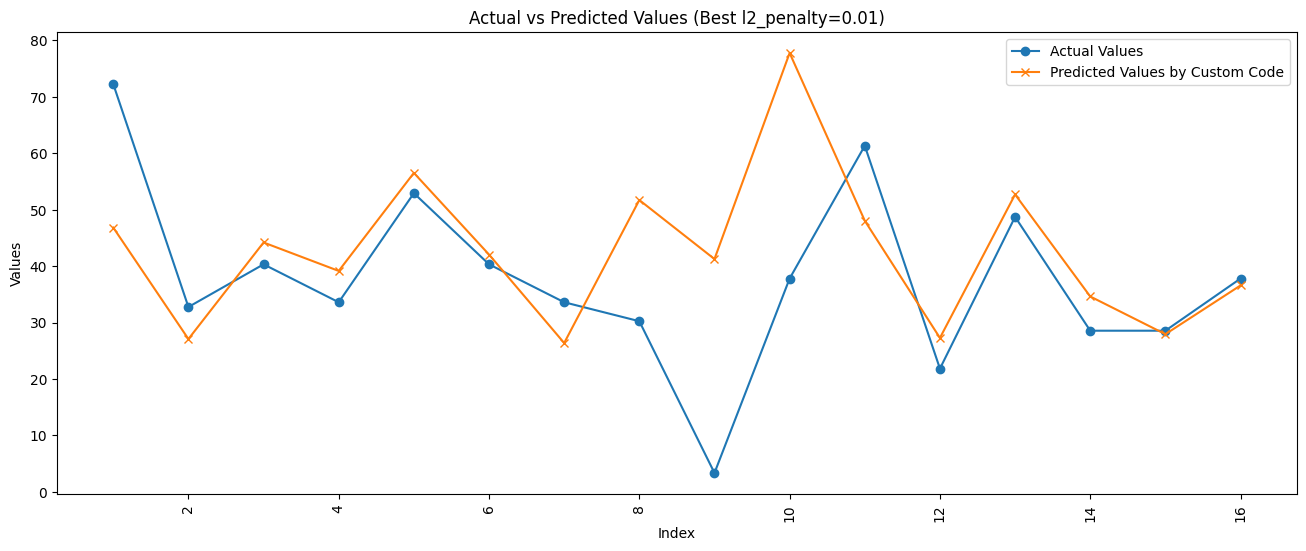

In [34]:
for i in range(0,len(brand)):
  print(brand[i])
  print(mape_test[i])
  # print(y_test[i])
  # print(y_pred[i])

  plt.figure(figsize=(16, 6))
  x_value = [i + 1 for i in range(len(y_test[i]))]
  plt.plot(x_value, y_test[i], label='Actual Values', marker='o')
  plt.plot(x_value, y_pred[i], label='Predicted Values by Custom Code', marker='x')

  # Adding title and labels
  plt.title(f'Actual vs Predicted Values (Best l2_penalty={best_l2_penalty})')
  plt.xlabel('Index')
  plt.ylabel('Values')
  plt.xticks(rotation=90)
  plt.legend()
  plt.show()